In [1]:
%matplotlib inline
import numpy as np
from scipy.special import lpmv
from math import factorial
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)

Building the spherical harmonic basis. Given a pair of integers(l, m) and a point (theta, phi) on the sphere, it returns the value of that particular spherical harmonic at that point.

In [3]:
def real_Y(l, m, theta, phi):
    am = abs(m)
    norm = np.sqrt((2 * l +1) / (4 * np.pi) * factorial(l - am) / factorial(l + am))
    P = lpmv(am, l, np.cos(theta))
    if m == 0:
        return norm * P
    elif m > 0:
        return np.sqrt(2) * norm * P * np.cos(am * phi)
    else:
        return np.sqrt(2) * norm * P * np.sin(am * phi)

The call function evaluates the spherical harmonics at different thetas and phis. The eval cart function takes our (x,y,z) vector, normalizes it, and the converts it into a (theta, phi) vector to be evaluated. This let's us treat f as a function on all of R^3 to allows to take an ordinary gradient. 

In [5]:
class SphericalFunction:
    def __init__(self, coeffs):
        self.coeffs = coeffs

    def __call__(self, theta, phi):
        val = 0.0 
        for (l, m), c in self.coeffs.items():
            val += c * real_Y(l, m, theta, phi)
        return val

    def eval_cart(self, v):
        v = np.asarray(v, dtype=float)
        r = np.linalg.norm(v)
        vhat = v/r
        theta = np.arccos(np.clip(vhat[2], -1.0, 1.0))
        phi = np.arctan2(vhat[1], vhat[0]) % (2 * np.pi)
        return self(theta, phi)

Wrapping the cartesian poly so that it can be used witht he same critical point machinery. 

In [7]:
class CartesianPolyFunction:
    def __init__(self, poly_func):
        self.poly_func = poly_func

    def eval_cart(self, v):
        v = np.asarray(v, dtype=float)
        vhat = v / np.linalg.norm(v)
        return self.poly_func(vhat[0], vhat[1], vhat[2])

For any point on the sphere the plane tangent is 2d, so here we build the orthonormal basis(e1,e2). 

In [9]:
def tangent_basis(v):
    helper = np.array([1.0, 0.0, 0.0])
    if abs(np.dot(helper, v)) > 0.9:
        helper = np.array([0.0, 1.0, 0.0])
    e1 = np.cross(v, helper)
    e1 /= np.linalg.norm(e1)
    e2 = np.cross(v, e1)
    e2 /= np.linalg.norm(e2)
    return e1, e2

We then take take the gradient.

In [11]:
def euclidean_gradient(F, v, h=1e-5):
    grad = np.zeros(3)
    for i in range(3):
        dv = np.zeros(3)
        dv[i] = h
        grad[i] = (F.eval_cart(v + dv) - F.eval_cart(v - dv)) / (2 * h)
    return grad

In [12]:
def tangential_gradient(F, v, h=1e-5):
    v = v / np.linalg.norm(v)
    g = euclidean_gradient(F, v, h)
    return g - np.dot(g, v) * v

Here we build the hessian which is a matrix of partial derivatives of f, and allows us to classify critical points, all partial derivatives must be 0. 

In [14]:
def tangential_hessian(F, v, h=1e-4):
    v = v / np.linalg.norm(v)
    e1, e2 = tangent_basis(v)

    def f_local(a, b):
        w = v + a * e1 + b * e2
        return F.eval_cart(w)

    f0 = f_local(0,0)
    fpp = f_local(h, 0); fmm = f_local(-h, 0)
    fqq = f_local(0, h); fnn = f_local(0, -h)
    fpq = f_local(h,h); fmn = f_local(-h, -h)
    fpn = f_local(h, -h); fmq = f_local(-h,h)

    d2f_da2 = (fpp - 2 * f0 + fmm) / h**2
    d2f_db2 = (fqq -2 *f0 +fnn) / h**2
    d2f_dadb = (fpq - fpn - fmq +fmn) / (4 * h**2)

    return np.array([[d2f_da2, d2f_dadb], [d2f_dadb, d2f_db2]])

Using Newton's method to find roots. 

In [16]:
def find_critical_point(F, v0, tol=1e-10, max_iter=100, damping=1.0):
    v = np.array(v0, dtype=float)
    v /= np.linalg.norm(v)

    for _ in range(max_iter):
        e1, e2 = tangent_basis(v)
        g = tangential_gradient(F, v)
        g_local = np.array([np.dot(g, e1), np.dot(g, e2)])
        if np.linalg.norm(g_local) < tol:
            break

        H = tangential_hessian(F, v)
        try:
            delta = np.linalg.solve(H, -g_local)
        except np.linalg.LinAlgError:
            delta = -g_local

        step_norm = np.linalg.norm(delta)
        if step_norm > 0.5:
            delta *= 0.5 / step_norm
        v = v + damping * (delta[0] * e1 + delta[1] * e2)
        v /= np.linalg.norm(v)

    return v, np.linalg.norm(tangential_gradient(F, v))

Defining a grid of points to start Newton's method on since Newton's method only converges to the critical point closest to the initial point. 

In [18]:
def fibonacci_sphere(n):
    points = []
    phi = np.pi * (3.0 - np.sqrt(5.0))
    for i in range(n):
        y = 1 - (i / float(n-1)) * 2
        radius = np.sqrt(1 - y *y)
        theta_f = phi * i
        x = np.cos(theta_f) * radius
        z = np.sin(theta_f) * radius
        points.append([x, y, z])
    return np.array(points)
    

In [19]:
def find_all_critical_points(F, n_starts=200, dedupe_tol=1e-3, grad_tol=1e-6):
    starts = fibonacci_sphere(n_starts)
    found = []
    for v0 in starts:
        v, gnorm = find_critical_point(F, v0)
        if gnorm > grad_tol:
            continue
        is_new = True
        for u in found:
            if np.linalg.norm(v - u) < dedupe_tol:
                is_new = False
                break
        if is_new:
            found.append(v)
    results = []
    for v in found:
        H = tangential_hessian(F, v)
        eigs = np.linalg.eigvalsh(H)
        if np.all(eigs > -1e-8):
            kind = "minimum"
        elif np.all(eigs < -1e-8):
            kind = "maximum"
        else:
            kind = "saddle"
        theta = np.arccos(np.clip(v[2], -1, 1))
        phi = np.arctan2(v[1], v[0]) % (2 * np.pi)
        results.append({
            "xyz": v, "theta": theta, "phi": phi,
            "value": F.eval_cart(v), "type": kind, "hessian_eigs": eigs,
        })
    return results

In [20]:
def morse_check(results):
    n_max = sum(1 for r in results if r["type"] == "maximum")
    n_min = sum(1 for r in results if r["type"] == "minimum")
    n_saddle = sum(1 for r in results if r["type"] == "saddle")
    return n_max, n_saddle, n_min, (n_max - n_saddle + n_min)

Generating our random coefficients. 

In [22]:
def random_spherical_function(l_max, scale=1.0, seed=None):
    rng = np.random.default_rng(seed)
    coeffs = {}
    for l in range(l_max + 1):
        for m in range(-l, l + 1):
            coeffs[(l, m)] = rng.normal(scale=scale / (l + 1))
    return SphericalFunction(coeffs)

In [23]:
MARKER_STYLE = {
    "maximum": dict(marker="^", color="red", s=90, label="maximum"),
    "minimum": dict(marker="v", color="blue", s=90, label="minimum"),
    "saddle":  dict(marker="o", color="black", s=70, label="saddle"),
}


def plot_function_with_critical_points(F, results, title, n_grid=120):
    theta = np.linspace(0, np.pi, n_grid)
    phi = np.linspace(0, 2 * np.pi, n_grid)
    theta_grid, phi_grid = np.meshgrid(theta, phi)

    x = np.sin(theta_grid) * np.cos(phi_grid)
    y = np.sin(theta_grid) * np.sin(phi_grid)
    z = np.cos(theta_grid)

    f_vals = np.vectorize(lambda t, p: F.eval_cart(
        [np.sin(t) * np.cos(p), np.sin(t) * np.sin(p), np.cos(t)]
    ))(theta_grid, phi_grid)

    f_min, f_max = f_vals.min(), f_vals.max()
    norm_vals = (f_vals - f_min) / (f_max - f_min + 1e-12)
    colors = plt.cm.viridis(norm_vals)

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(x, y, z, facecolors=colors, rstride=1, cstride=1,
                     linewidth=0, antialiased=False, shade=False, alpha=0.5)

    seen_labels = set()
    for r in results:
        style = MARKER_STYLE[r["type"]].copy()
        label = style.pop("label")
        if label in seen_labels:
            label = None
        else:
            seen_labels.add(style.get("label", None) or r["type"])
        pt = r["xyz"] * 1.15  # lift slightly off surface for visibility
        ax.scatter(*pt, **style, edgecolor="white", linewidth=1.2,
                    label=label if label else None, depthshade=False)

    ax.set_box_aspect([1, 1, 1])
    ax.set_title(title)
    ax.set_axis_off()
    ax.legend(loc="upper left", framealpha=0.9)

    mappable = plt.cm.ScalarMappable(cmap="viridis",
                                       norm=plt.Normalize(vmin=f_min, vmax=f_max))
    mappable.set_array([])
    fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.05, label="f value")

    plt.show()

In [24]:
A = np.diag([1.0, 2.0, 3.0])
F_quad = CartesianPolyFunction(
    lambda x, y, z: A[0,0]*x*x + A[1,1]*y*y + A[2,2]*z*z
)

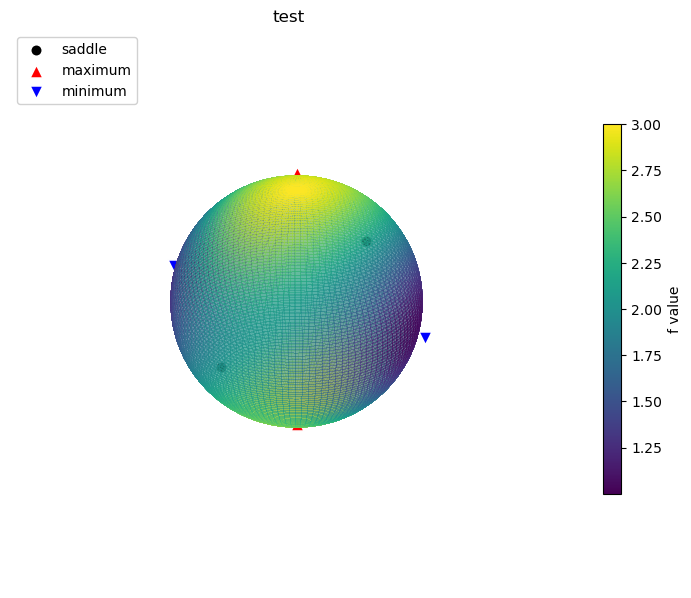

In [25]:
results_quad = find_all_critical_points(F_quad, n_starts=200)
plot_function_with_critical_points(F_quad, results_quad, title="test")

In [30]:
def random_biased_quadratic(seed=None, linear_scale=1.0, quad_scale=0.3):
    rng = np.random.default_rng(seed)
    c = rng.normal(size=3) * linear_scale
    M = rng.normal(size=(3, 3)) * quad_scale
    A = (M + M.T) / 2 

    def poly(x, y, z):
        v = np.array([x, y, z])
        return c @ v + v@ A @v

    return CartesianPolyFunction(poly)

F_deg2 = random_biased_quadratic(seed=0, linear_scale=1.0, quad_scale=0.3)
results_deg2 = find_all_critical_points(F_deg2, n_starts=200)
print("degree 2:", len(results_deg2), "critical points ->", [r["type"] for r in results_deg2])

degree 2: 2 critical points -> ['minimum', 'maximum']


In [42]:
def random_homogeneous_poly(degree, seed=None, scale=1.0):
    rng = np.random.default_rng(seed)
    exponents = [(i, j, degree - i - j)
                 for i in range(degree + 1)
                 for j in range(degree + 1 - i)]
    coeffs = {e: rng.normal(scale=scale) for e in exponents}

    def poly(x, y, z):
        val = 0.0
        for (i, j, k), c in coeffs.items():
            val += c * x**i * y**j * z**k
        return val

    return CartesianPolyFunction(poly)

F_deg4 = random_homogeneous_poly(4, seed=1)
F_deg6 = random_homogeneous_poly(6, seed=2)

results_deg4 = find_all_critical_points(F_deg4, n_starts=400, dedupe_tol=1e-3)
results_deg6 = find_all_critical_points(F_deg6, n_starts=800, dedupe_tol=5e-4)

print("degree 4:", len(results_deg4), "critical points ->", [r["type"] for r in results_deg4])
print("degree 6:", len(results_deg6), "critical points ->", [r["type"] for r in results_deg6])

for label, results in [("deg2", results_deg2), ("deg4", results_deg4), ("deg6", results_deg6)]:
    n_max, n_saddle, n_min, euler = morse_check(results)
    print(f"{label}: max={n_max} saddele={n_saddle} min={n_min}" f"uler_check={euler} (should be 2)")

degree 4: 14 critical points -> ['maximum', 'saddle', 'saddle', 'saddle', 'minimum', 'maximum', 'minimum', 'minimum', 'saddle', 'saddle', 'maximum', 'minimum', 'saddle', 'maximum']
degree 6: 18 critical points -> ['minimum', 'saddle', 'maximum', 'maximum', 'saddle', 'saddle', 'maximum', 'saddle', 'minimum', 'maximum', 'minimum', 'saddle', 'saddle', 'saddle', 'maximum', 'maximum', 'saddle', 'minimum']
deg2: max=1 saddele=0 min=1uler_check=2 (should be 2)
deg4: max=4 saddele=6 min=4uler_check=2 (should be 2)
deg6: max=6 saddele=8 min=4uler_check=2 (should be 2)


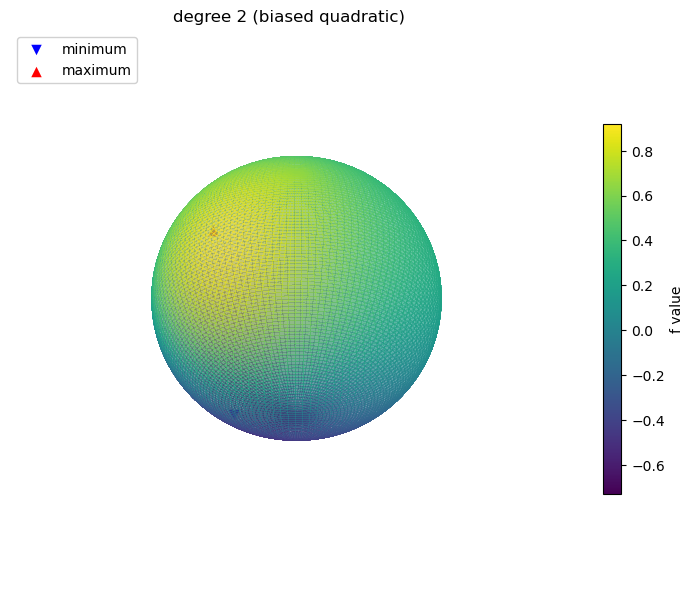

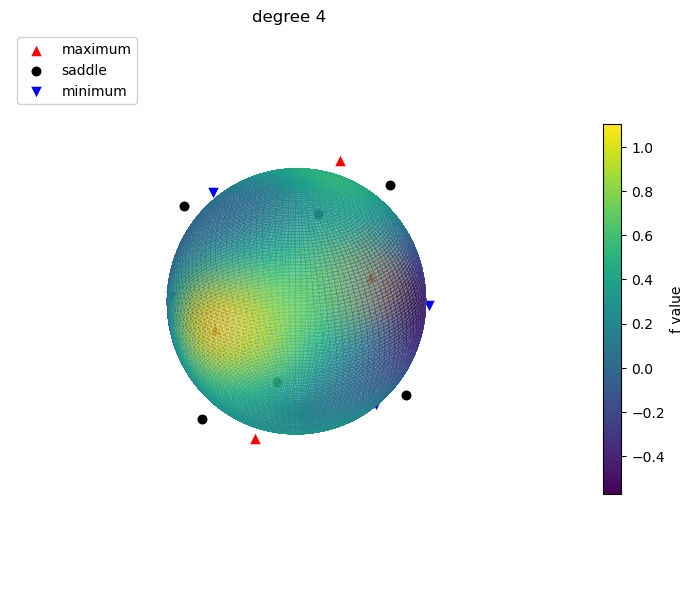

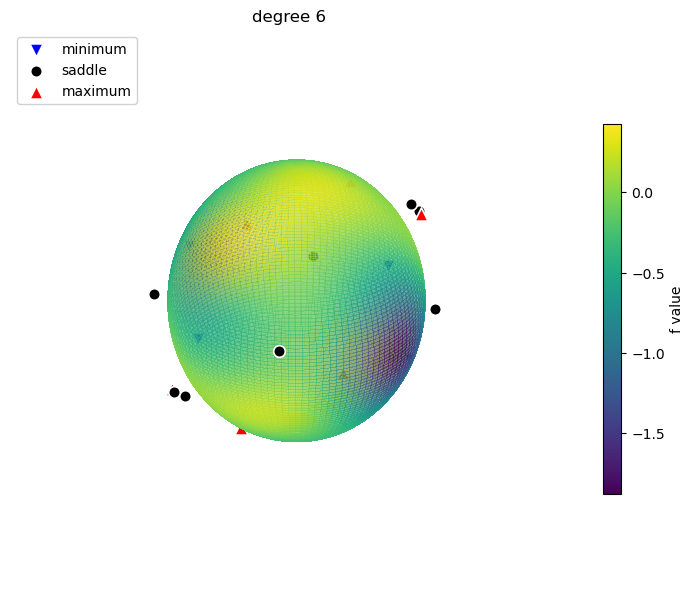

In [44]:
plot_function_with_critical_points(F_deg2, results_deg2, title ="degree 2 (biased quadratic)")
plot_function_with_critical_points(F_deg4, results_deg4, title="degree 4")
plot_function_with_critical_points(F_deg6, results_deg6, title="degree 6")